# Air Quality Analysis

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import geopandas as gpd
import contextily as ctx
import os
from sqlalchemy import create_engine, text
from sklearn.preprocessing import RobustScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import davies_bouldin_score, silhouette_score
from matplotlib.lines import Line2D

DB_USER = "admin"   
DB_PASS = "admin"
DB_HOST = "localhost"
DB_PORT = "5432"
DB_NAME = "pap"

DATABASE_URL = f"postgresql+psycopg2://{DB_USER}:{DB_PASS}@{DB_HOST}:{DB_PORT}/{DB_NAME}"
engine = create_engine(DATABASE_URL, future=True)

TARGET_POLLUTANTS = [
    "Biossido di Azoto",
    "PM10 (SM2005)",
    "Particelle sospese PM2.5",
    "Ozono",
]

LIMITS = {
    'PM10 (SM2005)': (45.0, 'µg/m³'),
    'Particelle sospese PM2.5': (15.0, 'µg/m³'),
    'Biossido di Azoto': (25.0, 'µg/m³'),
    'Ozono': (100.0, 'µg/m³'), # approximation based on 24-hour
}

POLLUTANT_COLORS = {
    'no2': '#4393c3',
    'pm10':'#e6550d',
    'pm25':'#d73027',
    'o3':'#74c476',
    'so2':'#9e9ac8',
}

POLLUTANT_SHORT = {
    'Biossido di Azoto': 'NO2',
    'PM10 (SM2005)': 'PM10',
    'Particelle sospese PM2.5': 'PM2.5',
    'Ozono': 'O3',
}

POLLUTANT_CODE = {
    'Biossido di Azoto': 'no2',
    'PM10 (SM2005)': 'pm10',
    'Particelle sospese PM2.5': 'pm25',
    'Ozono': 'o3',
}

URBAN_COLORS = {
    'Dense': '#d73027',
    'Intermediate': '#fdae61',
    'Rural': '#1a9850',
}
URBAN_ORDER = ['Dense', 'Intermediate', 'Rural']

URBAN_SHORT = {
    "Città/Zone densamente popolate": "Dense",
    "Piccole città/sobborghi o Zone a densità intermedia di popolazione": "Intermediate",
    "Zone rurali/sparse": "Rural",
}

STAT_COLORS = {
    'Min': '#4393c3',
    'Median': '#74c476',
    'Mean': '#fd8d3c',
    'Max': '#d73027',
}

AQI_COLORS = {
    'Good': '#50F0E6',
    'Fair': '#50CCAA',
    'Moderate': '#F0E641',
    'Poor': '#FF5050',
    'Very Poor': '#960032',
    'Extremely Poor': '#7D2181',
}

AQI_LABELS = {
    1: 'Good', 
    2: 'Fair',      
    3: 'Moderate',
    4: 'Poor',      
    5: 'Very Poor', 
    6: 'Extremely Poor'
}

AQI_ORDERED_LABELS = ["Good", "Fair", "Moderate", "Poor", "Very Poor", "Extremely Poor"]

IMGS_DIR = os.path.join('..', 'docs', 'images', '1_air_quality')
TABS_DIR = os.path.join('..', 'docs', 'tables', '1_air_quality')
os.makedirs(IMGS_DIR, exist_ok=True)
os.makedirs(TABS_DIR, exist_ok=True)


# Hierarchical Analysis

In [17]:
sql_urb = """
SELECT
    s.name AS pollutant,
    m.urbanization,
    ROUND(AVG(f.mean_value)::numeric, 2) AS mean_val,
    ROUND(MIN(f.mean_value)::numeric, 2) AS min_val,
    ROUND(MAX(f.mean_value)::numeric, 2) AS max_val,
    ROUND(PERCENTILE_CONT(0.5) WITHIN GROUP (ORDER BY f.mean_value)::numeric, 2) AS median_val,
    ROUND(STDDEV(f.mean_value)::numeric, 2) AS std_val
FROM pap.sample_ft f
JOIN pap.sensor_dt s ON s.sensor_id = f.sensor_id
JOIN pap.station_dt st ON st.station_id = s.station_id
JOIN pap.municipality_dt m ON m.municipality_id = st.municipality_id
JOIN pap.date_dt d ON d.date_id = f.date_id
WHERE d.year = 2023
  AND s.name = ANY(:target_pollutants)
  AND m.urbanization IS NOT NULL
GROUP BY s.name, m.urbanization
ORDER BY s.name, m.urbanization;
"""

sql_lombardy = """
SELECT
    s.name AS pollutant,
    ROUND(AVG(f.mean_value)::numeric, 2) AS mean_val,
    ROUND(MIN(f.mean_value)::numeric, 2) AS min_val,
    ROUND(MAX(f.mean_value)::numeric, 2) AS max_val,
    ROUND(PERCENTILE_CONT(0.5) WITHIN GROUP (ORDER BY f.mean_value)::numeric, 2) AS median_val,
    ROUND(STDDEV(f.mean_value)::numeric, 2) AS std_val
FROM pap.sample_ft f
JOIN pap.sensor_dt s ON s.sensor_id = f.sensor_id
JOIN pap.station_dt st ON st.station_id = s.station_id
JOIN pap.municipality_dt m ON m.municipality_id = st.municipality_id
JOIN pap.date_dt d ON d.date_id = f.date_id
WHERE d.year = 2023
  AND s.name = ANY(:target_pollutants)
GROUP BY s.name
ORDER BY s.name;
"""

with engine.connect() as con:
    df_urb = pd.read_sql(text(sql_urb), con, params={"target_pollutants": TARGET_POLLUTANTS})
    df_lombardy = pd.read_sql(text(sql_lombardy), con, params={"target_pollutants": TARGET_POLLUTANTS})

display(df_urb)
df_urb.to_csv(os.path.join(TABS_DIR, 'stats_by_urbanization.csv'), index=False)
display(df_lombardy)
df_lombardy.to_csv(os.path.join(TABS_DIR, 'stats_lombardy.csv'), index=False)

df_urb['urb_short'] = df_urb['urbanization'].map(lambda x: URBAN_SHORT.get(x, x))

stat_cols = ['min_val', 'median_val', 'mean_val', 'max_val']
stat_labels = list(STAT_COLORS.keys())
stat_colors = list(STAT_COLORS.values())


,pollutant,urbanization,mean_val,min_val,max_val,median_val,std_val
0,Biossido di Azoto,Città/Zone densamente popolate,29.49,0.87,133.15,27.38,14.84
1,Biossido di Azoto,Piccole città/sobborghi o Zone a densità inter...,21.12,0.91,111.80,18.74,11.64
2,Biossido di Azoto,Zone rurali/sparse,15.68,0.04,57.46,13.81,8.70
3,Ozono,Città/Zone densamente popolate,52.64,0.00,164.79,51.57,32.48
4,Ozono,Piccole città/sobborghi o Zone a densità inter...,53.41,0.02,172.39,54.23,30.81
5,Ozono,Zone rurali/sparse,55.33,0.68,181.27,57.01,29.80
6,Particelle sospese PM2.5,Città/Zone densamente popolate,17.95,0.00,88.00,14.00,12.35
7,Particelle sospese PM2.5,Piccole città/sobborghi o Zone a densità inter...,18.42,0.00,92.00,15.00,12.69
8,Particelle sospese PM2.5,Zone rurali/sparse,17.20,0.00,82.00,14.00,12.41
9,PM10 (SM2005),Città/Zone densamente popolate,25.88,0.00,113.60,22.00,15.44


,pollutant,mean_val,min_val,max_val,median_val,std_val
0,Biossido di Azoto,23.27,0.04,133.15,20.45,13.53
1,Ozono,53.63,0.00,181.27,54.14,31.13
2,Particelle sospese PM2.5,17.97,0.00,92.00,14.00,12.49
3,PM10 (SM2005),25.72,0.00,137.00,22.00,15.75


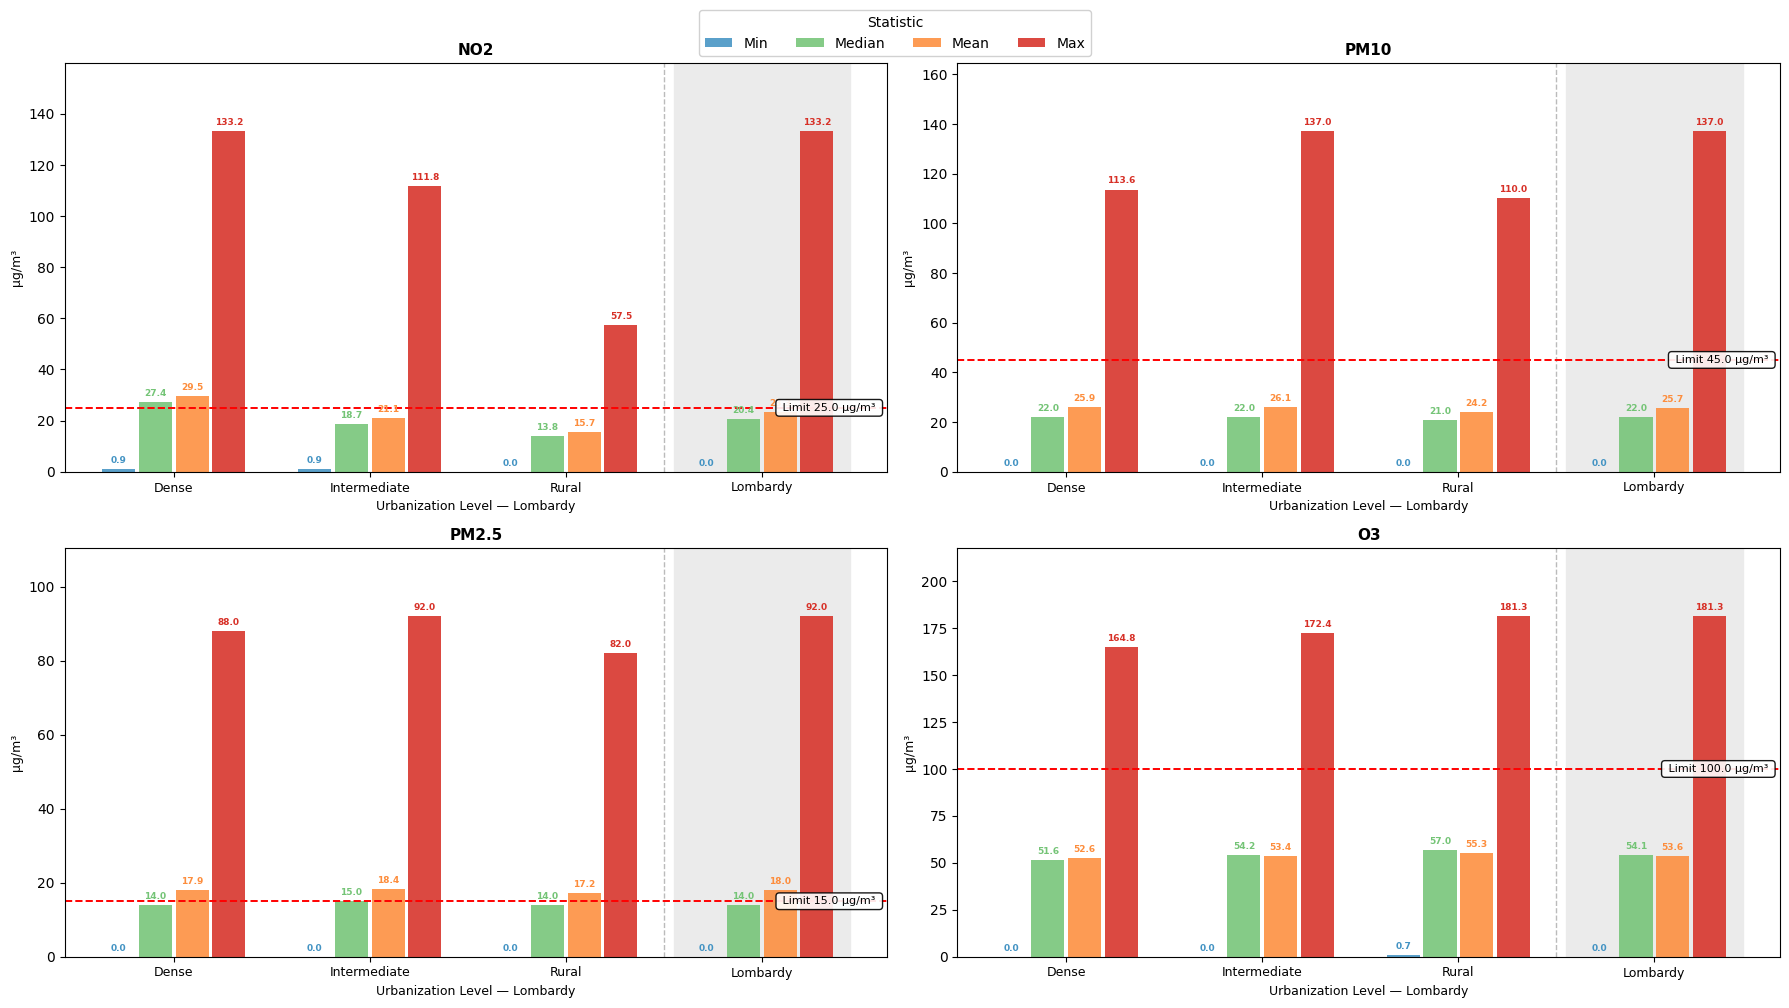

In [18]:
PLOT_POLLUTANTS = TARGET_POLLUTANTS

stat_cols = ['min_val', 'median_val', 'mean_val', 'max_val']
stat_labels = list(STAT_COLORS.keys())
stat_colors = list(STAT_COLORS.values())

n_polls = len(PLOT_POLLUTANTS)
n_cols = 2
n_rows = (n_polls + 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 10))
axes = axes.flatten()

total_w = 0.75
bar_w = total_w / len(stat_cols)

for ax_idx, pollutant in enumerate(PLOT_POLLUTANTS):
    ax = axes[ax_idx]

    sub_urb = df_urb[df_urb['pollutant'] == pollutant].copy()
    sub_urb['urb_short'] = pd.Categorical(sub_urb['urb_short'], categories=URBAN_ORDER, ordered=True)
    sub_urb = sub_urb.sort_values('urb_short')

    lom_row = df_lombardy[df_lombardy['pollutant'] == pollutant]
    lom_stats = {c: lom_row[c].values[0] if not lom_row.empty else np.nan for c in stat_cols}

    plot_df = sub_urb[['urb_short'] + stat_cols].rename(columns={'urb_short': 'group'})
    lom_df = pd.DataFrame({'group': ['Lombardy'], **{c: [v] for c, v in lom_stats.items()}})
    plot_df = pd.concat([plot_df, lom_df], ignore_index=True)

    x = np.arange(len(plot_df))
    ymax = plot_df['max_val'].max()
    lbl_off = ymax * 0.012
    limit_val, unit = LIMITS.get(pollutant, (None, None))
    visible_top = max(ymax * 1.20, limit_val * 1.08) if limit_val else ymax * 1.20

    ax.set_ylim(0, visible_top)
    
    lom_idx = list(plot_df['group']).index('Lombardy')
    ax.axvspan(lom_idx - 0.45, lom_idx + 0.45, color='#ebebeb', zorder=0)
    ax.axvline(lom_idx - 0.5, color='#bbbbbb', linewidth=1, linestyle='--', zorder=1)

    for i, (col, label, color) in enumerate(zip(stat_cols, stat_labels, stat_colors)):
        offsets = x - total_w / 2 + (i + 0.5) * bar_w
        heights = plot_df[col].values
        bars = ax.bar(offsets, heights, width=bar_w * 0.9,
                      label=label, color=color, alpha=0.88)
        for bar, h in zip(bars, heights):
            ax.text(bar.get_x() + bar.get_width() / 2, h + lbl_off,
                    f'{h:.1f}', ha='center', va='bottom',
                    fontsize=6.5, fontweight='bold', color=color)

    short = POLLUTANT_SHORT.get(pollutant, pollutant)
    ax.set_xticks(x)
    ax.set_xticklabels(plot_df['group'].tolist(), fontsize=9)
    ax.set_title(f'{short}', fontsize=11, fontweight='bold')
    ax.set_ylabel(f'µg/m³', fontsize=9)
    ax.set_xlabel('Urbanization Level — Lombardy', fontsize=9)
    ax.grid(False)

    if limit_val is not None:
        ax.axhline(y=limit_val, color='r', linestyle='--', linewidth=1.4)
        ax.text(0.99, limit_val, f' Limit {limit_val} {unit} ',
                transform=ax.get_yaxis_transform(), fontsize=8, color='black',
                va='center', ha='right',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                          edgecolor='black', linewidth=1, alpha=0.9))

for j in range(n_polls, len(axes)):
    axes[j].set_visible(False)

from matplotlib.patches import Patch
legend_handles = [Patch(facecolor=c, alpha=0.88, label=l) for l, c in zip(stat_labels, stat_colors)]
fig.legend(handles=legend_handles, title='Statistic', loc='upper center',
           ncol=len(stat_labels), fontsize=10, title_fontsize=10,
           framealpha=0.9, bbox_to_anchor=(0.5, 1.01))
plt.suptitle("")
plt.tight_layout()
fig.savefig(os.path.join(IMGS_DIR, 'hierarchical_stats_combined.png'), dpi=150, bbox_inches='tight')
plt.show()


# Critical Pollution Windows

In [19]:
sql_windows = """
    WITH daily_avg AS (
        SELECT
            d.date,
            m.name AS municipality,
            AVG(f.mean_value) AS daily_val,
            CASE WHEN AVG(f.mean_value) > :threshold THEN 1 ELSE 0 END AS is_critical
        FROM pap.sample_ft f
        JOIN pap.sensor_dt s ON s.sensor_id = f.sensor_id
        JOIN pap.station_dt st ON st.station_id = s.station_id
        JOIN pap.municipality_dt m ON m.municipality_id = st.municipality_id
        JOIN pap.date_dt d ON d.date_id = f.date_id
        WHERE d.year = 2023
        AND s.name = :pollutant
        GROUP BY d.date, m.name
    ),
    FLAGGED AS (
        SELECT
            date,
            municipality,
            daily_val,
            LAG(date)  OVER (PARTITION BY municipality ORDER BY date) AS prev_date,
            LEAD(date) OVER (PARTITION BY municipality ORDER BY date) AS next_date
        FROM daily_avg
        WHERE is_critical = 1
    ),
    GROUP_STARTS AS (
        SELECT date AS grp_start, municipality
        FROM FLAGGED
        WHERE prev_date IS NULL OR date - prev_date > 1
    ),
    GROUP_ENDS AS (
        SELECT date AS grp_end, municipality
        FROM FLAGGED
        WHERE next_date IS NULL OR next_date - date > 1
    ),
    EPISODES AS (
        SELECT
            s.municipality,
            s.grp_start,
            MIN(e.grp_end) AS grp_end
        FROM GROUP_STARTS s
        JOIN GROUP_ENDS e ON e.municipality = s.municipality AND e.grp_end >= s.grp_start
        GROUP BY s.municipality, s.grp_start
    )
    SELECT
        e.municipality,
        e.grp_start AS start_date,
        e.grp_end AS end_date,
        COUNT(*) AS consecutive_days,
        ROUND(AVG(f.daily_val)::numeric, 1) AS avg_val
    FROM EPISODES e
    JOIN FLAGGED f ON f.municipality = e.municipality
        AND f.date BETWEEN e.grp_start AND e.grp_end
    GROUP BY e.municipality, e.grp_start, e.grp_end
    ORDER BY consecutive_days DESC, avg_val DESC
    LIMIT 10;
"""

for pollutant in TARGET_POLLUTANTS:
    limit_val, unit = LIMITS[pollutant]
    short = POLLUTANT_SHORT.get(pollutant, pollutant)

    with engine.connect() as con:
        df_win = pd.read_sql(
            text(sql_windows), con,
            params={"pollutant": pollutant, "threshold": limit_val}
        )

    print(f"\nCritical Windows - {short} > {limit_val} {unit}:")
    if df_win.empty:
        print("No critical windows found.")
        continue

    display(df_win)
    df_win.to_csv(os.path.join(TABS_DIR, f'critical_windows_{POLLUTANT_CODE[pollutant]}.csv'), index=False)



Critical Windows - NO2 > 25.0 µg/m³:


,municipality,start_date,end_date,consecutive_days,avg_val
0,Bergamo,2023-01-01,2023-04-08,98,45.5
1,Cinisello Balsamo,2023-01-01,2023-03-26,85,54.5
2,Milano,2023-10-16,2023-12-31,77,43.2
3,Sesto San Giovanni,2023-10-30,2023-12-31,63,52.9
4,Rho,2023-11-06,2023-12-31,56,44.3
5,Brescia,2023-11-06,2023-12-31,56,38.8
6,San Giuliano Milanese,2023-11-06,2023-12-23,48,39.6
7,Pavia,2023-11-06,2023-12-23,48,38.2
8,Sondrio,2023-01-12,2023-02-24,44,38.2
9,Cinisello Balsamo,2023-06-12,2023-07-25,44,35.3



Critical Windows - PM10 > 45.0 µg/m³:


,municipality,start_date,end_date,consecutive_days,avg_val
0,Mantova,2023-02-10,2023-02-25,16,78.9
1,Rezzato,2023-02-13,2023-02-24,12,99.1
2,Ponti sul Mincio,2023-02-14,2023-02-25,12,80.2
3,Brescia,2023-02-14,2023-02-25,12,80.1
4,Odolo,2023-02-14,2023-02-24,11,73.0
5,Meda,2023-12-11,2023-12-21,11,59.9
6,Darfo Boario Terme,2023-02-15,2023-02-24,10,68.6
7,Cremona,2023-02-10,2023-02-17,8,76.8
8,Soresina,2023-02-10,2023-02-17,8,76.4
9,Codogno,2023-02-10,2023-02-17,8,74.5



Critical Windows - PM2.5 > 15.0 µg/m³:


,municipality,start_date,end_date,consecutive_days,avg_val
0,Sondrio,2023-01-01,2023-02-25,56,29.4
1,Spinadesco,2023-11-07,2023-12-21,45,35.6
2,Darfo Boario Terme,2023-01-01,2023-02-05,36,33.9
3,Parona,2023-01-22,2023-02-26,36,33.0
4,Sondrio,2023-11-26,2023-12-31,36,27.8
5,Spinadesco,2023-01-01,2023-02-04,35,36.5
6,Parona,2023-12-04,2023-12-31,28,31.1
7,Treviglio,2023-01-11,2023-02-05,26,32.3
8,Brescia,2023-01-10,2023-02-04,26,28.5
9,Soresina,2023-01-11,2023-02-04,25,38.1



Critical Windows - O3 > 100.0 µg/m³:


,municipality,start_date,end_date,consecutive_days,avg_val
0,Moggio,2023-06-06,2023-06-30,25,120.1
1,Moggio,2023-08-09,2023-08-26,18,132.1
2,Moggio,2023-09-28,2023-10-12,15,139.6
3,Erba,2023-06-15,2023-06-29,15,118.5
4,Moggio,2023-05-21,2023-06-04,15,117.4
5,Bergamo,2023-06-16,2023-06-29,14,117.5
6,Brescia,2023-06-16,2023-06-29,14,116.9
7,Voghera,2023-06-16,2023-06-29,14,116.2
8,Lecco,2023-06-16,2023-06-29,14,113.6
9,Brescia,2023-08-14,2023-08-26,13,118.7


In [20]:
df_windows_by_pollutant = {}
for pollutant in TARGET_POLLUTANTS:
    limit_val, unit = LIMITS[pollutant]
    short = POLLUTANT_SHORT.get(pollutant, pollutant)
    with engine.connect() as con:
        df_win = pd.read_sql(
            text(sql_windows), con,
            params={"pollutant": pollutant, "threshold": limit_val}
        )
    df_windows_by_pollutant[pollutant] = df_win


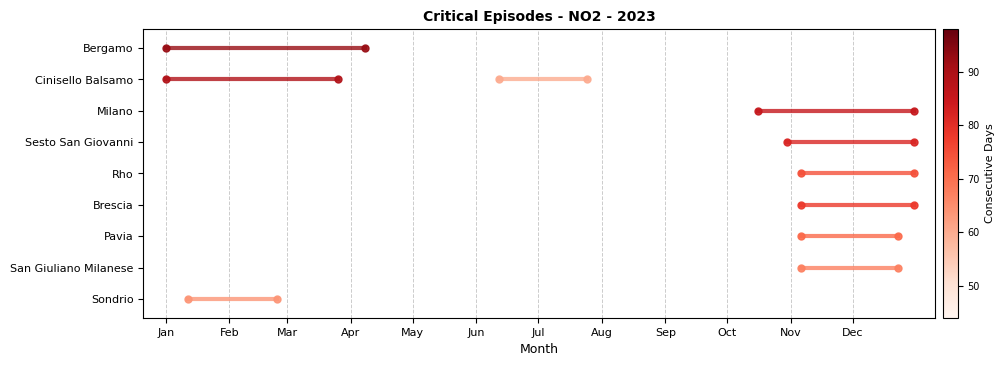

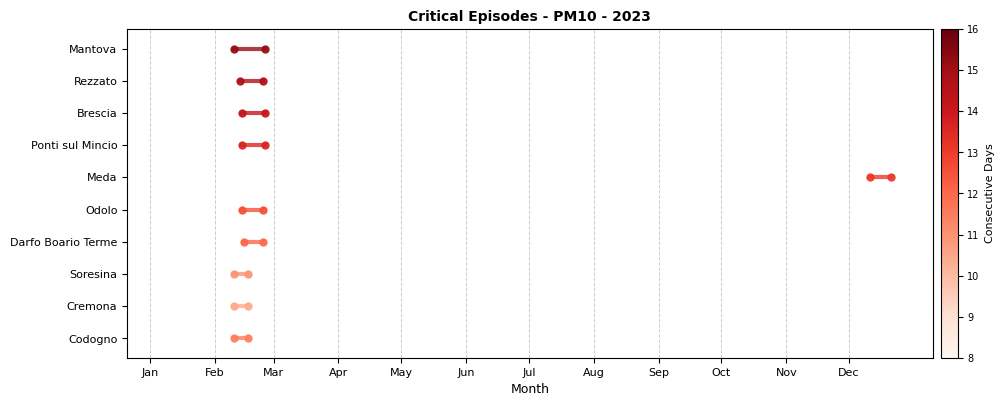

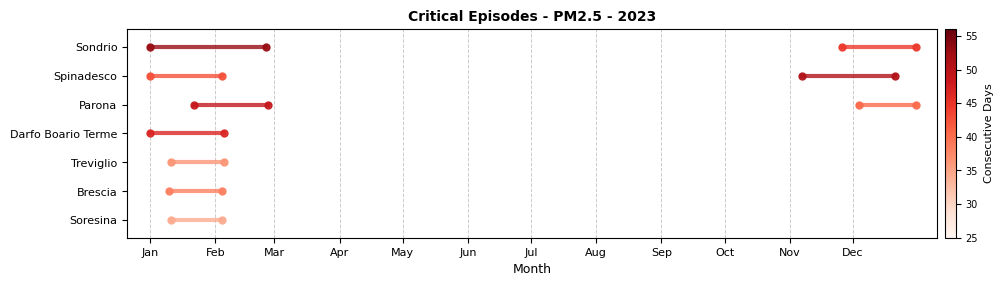

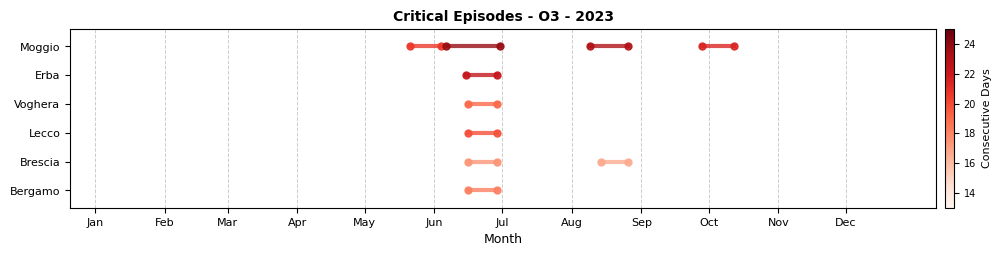

In [21]:
for pollutant in TARGET_POLLUTANTS:
    limit_val, unit = LIMITS[pollutant]
    short = POLLUTANT_SHORT.get(pollutant, pollutant)

    df_win = df_windows_by_pollutant[pollutant]

    if df_win.empty:
        continue

    df_win_plot = df_win.copy()
    df_win_plot['start_day'] = pd.to_datetime(df_win_plot['start_date']).dt.dayofyear
    df_win_plot['end_day'] = pd.to_datetime(df_win_plot['end_date']).dt.dayofyear

    muni_order = (
        df_win_plot.groupby('municipality')['consecutive_days'].max()
        .sort_values(ascending=True).index.tolist()
    )
    n_munis = len(muni_order)
    muni_to_y = {m: i for i, m in enumerate(muni_order)}

    n_eps = len(df_win_plot)
    df_win_plot = df_win_plot.sort_values('consecutive_days', ascending=True).reset_index(drop=True)
    episode_colors = plt.cm.Reds(np.linspace(0.3, 0.9, n_eps))

    fig, ax = plt.subplots(figsize=(10, max(2.5, n_munis * 0.4)))

    for idx, row in df_win_plot.iterrows():
        muni = row['municipality']
        i = muni_to_y[muni]
        color = episode_colors[idx]
        x_start = row['start_day']
        x_end = row['end_day']

        ax.plot([x_start, x_end], [i, i], '-', linewidth=3, color=color, alpha=0.8, zorder=2)
        ax.plot(x_start, i, 'o', markersize=5, color=color, alpha=0.9, zorder=3)
        ax.plot(x_end, i, 'o', markersize=5, color=color, alpha=0.9, zorder=3)

    month_starts = [pd.Timestamp(f'2023-{m:02d}-01').dayofyear for m in range(1, 13)]
    month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun','Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

    municipalities_labels = [m for m in muni_order]
    ax.set_yticks(np.arange(n_munis))
    ax.set_yticklabels(municipalities_labels, fontsize=8)
    ax.set_xlabel('Month', fontsize=9)
    ax.set_title(f'Critical Episodes - {short} - 2023', fontsize=10, fontweight='bold')
    ax.set_xlim(-10, 375)
    ax.set_xticks(month_starts)
    ax.set_xticklabels(month_names, fontsize=8)
    ax.set_ylim(-0.6, n_munis - 0.4)
    for ms in month_starts:
        ax.axvline(ms, color='#cccccc', linewidth=0.7, linestyle='--', zorder=0)
    ax.grid(axis='x', alpha=0)
    ax.set_axisbelow(True)
    ax.tick_params(axis='both', labelsize=8)

    sm = plt.cm.ScalarMappable(cmap='Reds', norm=plt.Normalize(
        vmin=df_win_plot['consecutive_days'].min(),
        vmax=df_win_plot['consecutive_days'].max()
    ))
    sm.set_array([])
    cbar = plt.colorbar(sm, ax=ax, orientation='vertical', pad=0.01, fraction=0.03)
    cbar.set_label('Consecutive Days', fontsize=8)
    cbar.ax.tick_params(labelsize=7)

    plt.tight_layout(pad=0.5)
    plt.savefig(os.path.join(IMGS_DIR, f'critical_episodes_{POLLUTANT_CODE[pollutant]}.png'), dpi=150, bbox_inches='tight')
    plt.show()


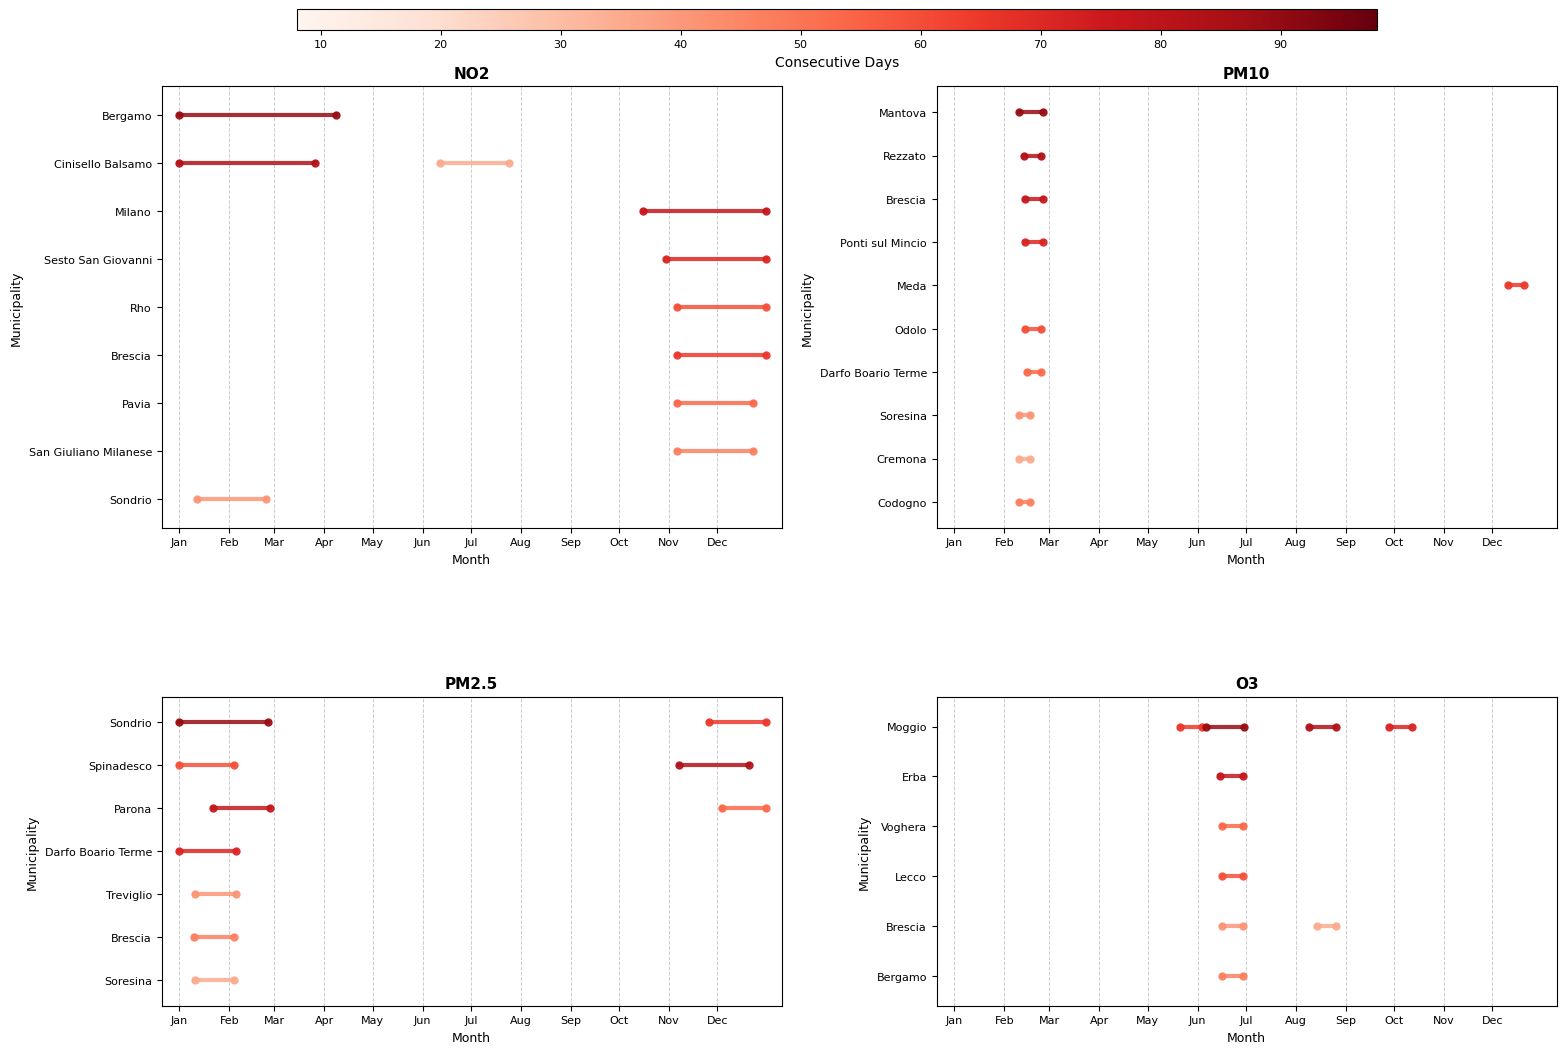

In [22]:
def _n_munis(p):
    df = df_windows_by_pollutant.get(p, pd.DataFrame())
    return max(df['municipality'].nunique(), 1) if not df.empty else 1

n_munis_list = [_n_munis(p) for p in TARGET_POLLUTANTS]

row0_h = max(n_munis_list[0], n_munis_list[1])
row1_h = max(n_munis_list[2], n_munis_list[3]) if len(n_munis_list) > 3 else n_munis_list[2]

global_min_days = min(
    df_windows_by_pollutant[p]['consecutive_days'].min()
    for p in TARGET_POLLUTANTS if not df_windows_by_pollutant[p].empty
)
global_max_days = max(
    df_windows_by_pollutant[p]['consecutive_days'].max()
    for p in TARGET_POLLUTANTS if not df_windows_by_pollutant[p].empty
)
norm_shared = plt.Normalize(vmin=global_min_days, vmax=global_max_days)
cmap_shared = plt.cm.Reds

month_starts = [pd.Timestamp(f'2023-{m:02d}-01').dayofyear for m in range(1, 13)]
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

fig = plt.figure(figsize=(18, (row0_h + row1_h) * 0.55 + 2))
gs  = fig.add_gridspec(
    2, 2,
    height_ratios=[row0_h, row1_h],
    hspace=0.45,
    wspace=0.25,
    top=0.86,
    bottom=0.05,
)

axes = [
    fig.add_subplot(gs[0, 0]),
    fig.add_subplot(gs[0, 1]),
    fig.add_subplot(gs[1, 0]),
    fig.add_subplot(gs[1, 1]),
]

for ax_idx, pollutant in enumerate(TARGET_POLLUTANTS):
    ax = axes[ax_idx]
    short = POLLUTANT_SHORT.get(pollutant, pollutant)
    limit_val, unit = LIMITS[pollutant]
    df_win = df_windows_by_pollutant.get(pollutant, pd.DataFrame())

    if df_win.empty:
        ax.set_visible(False)
        continue

    df_win_plot = df_win.copy()
    df_win_plot['start_day'] = pd.to_datetime(df_win_plot['start_date']).dt.dayofyear
    df_win_plot['end_day'] = pd.to_datetime(df_win_plot['end_date']).dt.dayofyear
    df_win_plot = df_win_plot.sort_values('consecutive_days', ascending=True).reset_index(drop=True)

    muni_order = (
        df_win_plot.groupby('municipality')['consecutive_days'].max()
        .sort_values(ascending=True).index.tolist()
    )
    n_munis = len(muni_order)
    muni_to_y = {m: i for i, m in enumerate(muni_order)}

    n_eps = len(df_win_plot)
    episode_colors = cmap_shared(np.linspace(0.3, 0.9, n_eps))

    for idx, (_, row) in enumerate(df_win_plot.iterrows()):
        i = muni_to_y[row['municipality']]
        color = episode_colors[idx]
        ax.plot([row['start_day'], row['end_day']], [i, i], '-', linewidth=3, color=color, alpha=0.85, zorder=2)
        ax.plot(row['start_day'], i, 'o', markersize=5, color=color, alpha=0.9, zorder=3)
        ax.plot(row['end_day'],   i, 'o', markersize=5, color=color, alpha=0.9, zorder=3)

    ax.set_yticks(np.arange(n_munis))
    ax.set_yticklabels(muni_order, fontsize=8)
    ax.set_ylabel('Municipality', fontsize=9)
    ax.set_title(f'{short}', fontsize=11, fontweight='bold')
    ax.set_xlabel('Month', fontsize=9)
    ax.set_xlim(-10, 375)
    ax.set_xticks(month_starts)
    ax.set_xticklabels(month_names, fontsize=8)
    ax.set_ylim(-0.6, n_munis - 0.4)
    for ms in month_starts:
        ax.axvline(ms, color='#cccccc', linewidth=0.7, linestyle='--', zorder=0)
    ax.tick_params(axis='both', labelsize=8)

sm = plt.cm.ScalarMappable(cmap=cmap_shared, norm=norm_shared)
sm.set_array([])
cbar_ax = fig.add_axes([0.20, 0.91, 0.60, 0.018])
cbar = fig.colorbar(sm, cax=cbar_ax, orientation='horizontal')
cbar.set_label('Consecutive Days', fontsize=10)
cbar.ax.tick_params(labelsize=8)

fig.savefig(os.path.join(IMGS_DIR, 'critical_episodes_combined.png'), dpi=150, bbox_inches='tight')
plt.show()


# Dynamic Ranking

In [23]:
sql_rank = """
WITH monthly_avgs AS (
    SELECT
        d.month,
        m.name AS municipality,
        m.urbanization,
        AVG(f.mean_value) AS val
    FROM pap.sample_ft f
    JOIN pap.sensor_dt s ON s.sensor_id = f.sensor_id
    JOIN pap.station_dt st ON st.station_id = s.station_id
    JOIN pap.municipality_dt m ON m.municipality_id = st.municipality_id
    JOIN pap.date_dt d ON d.date_id = f.date_id
    WHERE d.year = 2023 AND s.name = :pollutant
    GROUP BY d.month, m.name, m.urbanization
),
RANKED AS (
    SELECT
        month,
        municipality,
        urbanization,
        ROUND(val::numeric, 2) AS val,
        ROW_NUMBER() OVER (PARTITION BY month ORDER BY val DESC) AS rnk
    FROM monthly_avgs
)
SELECT *
FROM RANKED
WHERE rnk <= 5
ORDER BY month, rnk;
"""

PARTICULATE_POLLUTANTS = ["PM10 (SM2005)", "Particelle sospese PM2.5"]

all_ranks = []
for pollutant in PARTICULATE_POLLUTANTS:
    with engine.connect() as con:
        df_rank = pd.read_sql(text(sql_rank), con, params={"pollutant": pollutant})
    df_rank['pollutant'] = pollutant
    all_ranks.append(df_rank)

    limit_info = f" (limit: {LIMITS[pollutant][0]} {LIMITS[pollutant][1]})" if pollutant in LIMITS else ""
    print(f"Top 5 Municipalities per Month - {pollutant}{limit_info}")

    pivot = df_rank.pivot(index='month', columns='rnk', values='municipality')
    pivot.columns = [f"{i}" for i in pivot.columns]
    pivot.index = pivot.index.map(lambda m: pd.Timestamp(2023, m, 1).strftime('%B'))
    pivot.index.name = 'Month'
    display(pivot)
    pivot.to_csv(os.path.join(TABS_DIR, f'top5_monthly_ranking_{POLLUTANT_CODE[pollutant]}.csv'))

df_all_ranks = pd.concat(all_ranks, ignore_index=True)


Top 5 Municipalities per Month - PM10 (SM2005) (limit: 45.0 µg/m³)


,1,2,3,4,5
Month,,,,,
gennaio,Darfo Boario Terme,Rezzato,Soresina,Codogno,Meda
febbraio,Rezzato,Mantova,Ponti sul Mincio,Brescia,Soresina
marzo,Rezzato,Soresina,Codogno,Brescia,Casirate d'Adda
aprile,Spinadesco,Soresina,Casirate d'Adda,Dalmine,Darfo Boario Terme
maggio,Spinadesco,Soresina,Codogno,Casirate d'Adda,Brescia
giugno,Borgocarbonara,Spinadesco,Codogno,Rezzato,Soresina
luglio,Borgocarbonara,Spinadesco,Soresina,Casirate d'Adda,Codogno
agosto,Soresina,Codogno,Spinadesco,Crema,Borgocarbonara
settembre,Soresina,Spinadesco,Casirate d'Adda,Cremona,Crema


Top 5 Municipalities per Month - Particelle sospese PM2.5 (limit: 15.0 µg/m³)


,1,2,3,4,5
Month,,,,,
gennaio,Spinadesco,Soresina,Darfo Boario Terme,Treviglio,Cremona
febbraio,Ponti sul Mincio,Mantova,Soresina,Spinadesco,Brescia
marzo,Soresina,Casirate d'Adda,Spinadesco,Bergamo,Treviglio
aprile,Spinadesco,Casirate d'Adda,Dalmine,Soresina,Treviglio
maggio,Bergamo,Spinadesco,Casirate d'Adda,Treviglio,Pavia
giugno,Dalmine,Treviglio,Casirate d'Adda,Spinadesco,Saronno
luglio,Casirate d'Adda,Cornale e Bastida,Soresina,Cremona,Spinadesco
agosto,Spinadesco,Soresina,Casirate d'Adda,Cremona,Cornale e Bastida
settembre,Casirate d'Adda,Soresina,Spinadesco,Cremona,Cornale e Bastida


In [24]:
for pollutant in PARTICULATE_POLLUTANTS:
    short = POLLUTANT_SHORT.get(pollutant, pollutant)
    sub = df_all_ranks[df_all_ranks['pollutant'] == pollutant].copy()
    sub['urb_short'] = sub['urbanization'].map(lambda x: URBAN_SHORT.get(x, x))
    counts = sub['urb_short'].value_counts().reindex(URBAN_ORDER).fillna(0).astype(int)
    pct = (counts / counts.sum() * 100).round(1)
    result = pd.DataFrame({'Count': counts, 'Percentage (%)': pct})
    result.index.name = 'Urbanization'
    print(f"Urbanization distribution of top-10 rankings — {short}")
    display(result)
    result.to_csv(os.path.join(TABS_DIR, f'top5_urb_distribution_{POLLUTANT_CODE[pollutant]}.csv'))


Urbanization distribution of top-10 rankings — PM10


,Count,Percentage (%)
Urbanization,,
Dense,8,13.3
Intermediate,41,68.3
Rural,11,18.3


Urbanization distribution of top-10 rankings — PM2.5


,Count,Percentage (%)
Urbanization,,
Dense,12,20.0
Intermediate,31,51.7
Rural,17,28.3


# Clustering Municipalities

PCA: 1460 feature → 21 components (95% variance)


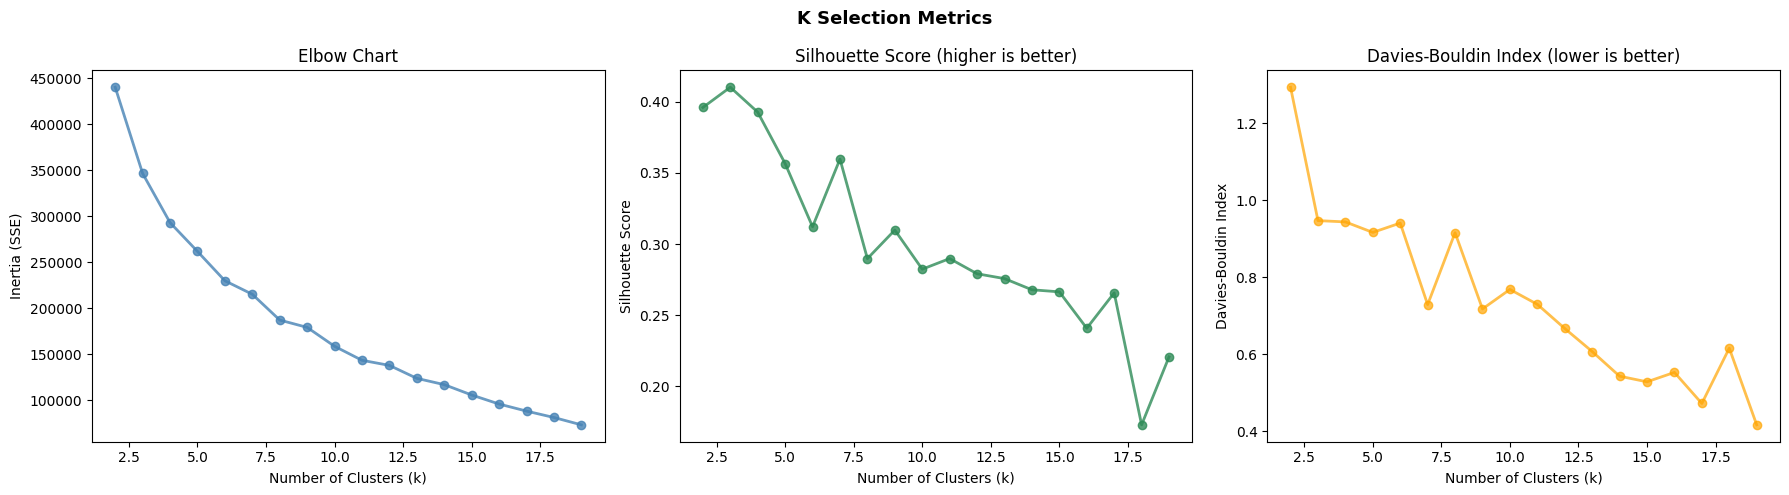

Selected k = 3


C:\Users\acoss\AppData\Local\Temp\ipykernel_16084\93014371.py:107: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_pivot_wide["cluster"] = kmeans.fit_predict(X_reduced)


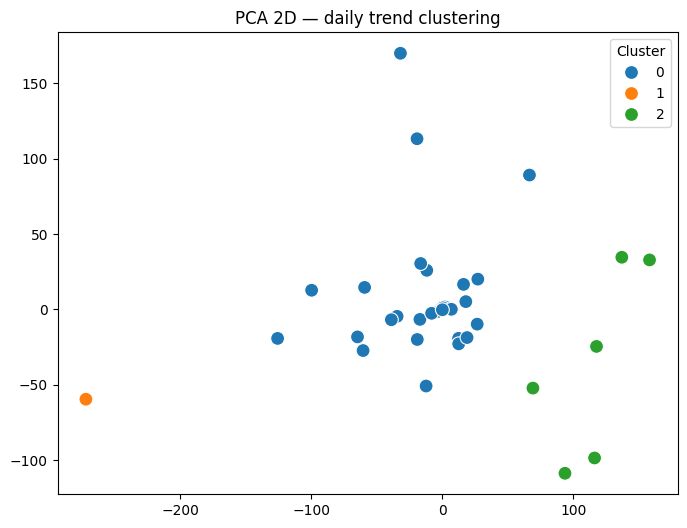

In [25]:
SQL_CLUSTER_DAILY = """
WITH mapped_pollutants AS (
    SELECT
        m.municipality_id,
        m.name AS municipality_name,
        d.date,
        CASE sen.name
            WHEN 'Biossido di Azoto'          THEN 'no2'
            WHEN 'PM10 (SM2005)'              THEN 'pm10'
            WHEN 'Particelle sospese PM2.5'   THEN 'pm25'
            WHEN 'Ozono'                      THEN 'o3'
        END AS pollutant,
        AVG(sft.mean_value) AS daily_avg
    FROM pap.sample_ft AS sft
    JOIN pap.sensor_dt AS sen ON sft.sensor_id = sen.sensor_id
    JOIN pap.station_dt AS st  ON sen.station_id = st.station_id
    JOIN pap.municipality_dt AS m ON st.municipality_id = m.municipality_id
    JOIN pap.date_dt AS d ON d.date_id = sft.date_id
    WHERE sen.name = ANY(:cluster_pollutants)
      AND d.year = 2023
    GROUP BY m.municipality_id, m.name, d.date, sen.name
)
SELECT municipality_id, municipality_name, date, pollutant, daily_avg
FROM mapped_pollutants
ORDER BY municipality_id, pollutant, date;
"""

with engine.connect() as con:
    df_daily_raw = pd.read_sql(text(SQL_CLUSTER_DAILY), con, params={"cluster_pollutants": TARGET_POLLUTANTS})

df_daily_raw['date'] = pd.to_datetime(df_daily_raw['date'])

df_pivot_wide = df_daily_raw.pivot_table(
    index=["municipality_id", "municipality_name"],
    columns=["pollutant", "date"],
    values="daily_avg",
    aggfunc="mean"
)
df_pivot_wide.columns = [f"{p}_{d.strftime('%m%d')}" for p, d in df_pivot_wide.columns]
df_pivot_wide = df_pivot_wide.reset_index()

feature_cols = [c for c in df_pivot_wide.columns if c not in ["municipality_id", "municipality_name"]]
mask = df_pivot_wide[feature_cols].notna().mean(axis=1) >= 0.50
df_pivot_wide = df_pivot_wide[mask].reset_index(drop=True)

df_pivot_wide[feature_cols] = df_pivot_wide[feature_cols].apply(
    lambda col: col.fillna(col.median())
)

X = df_pivot_wide[feature_cols].values
scaler = RobustScaler()
X_scaled = scaler.fit_transform(X)

pca_pre = PCA(n_components=0.95, random_state=42)
X_reduced = pca_pre.fit_transform(X_scaled)
print(f"PCA: {X_scaled.shape[1]} feature → {X_reduced.shape[1]} components (95% variance)")

# K selection metrics
k_range = range(2, 20)
davies_bouldin_scores = []
silhouette_scores = []
inertias = []

for k in k_range:
    kmeans_temp = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans_temp.fit_predict(X_reduced)
    davies_bouldin_scores.append(davies_bouldin_score(X_reduced, labels))
    silhouette_scores.append(silhouette_score(X_reduced, labels))
    inertias.append(kmeans_temp.inertia_)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Elbow chart
axes[0].plot(k_range, inertias, 'o-', linewidth=2, markersize=6, color='steelblue', alpha=0.8)
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('Inertia (SSE)')
axes[0].set_title('Elbow Chart')
axes[0].grid(False)

# Silhouette score
axes[1].plot(k_range, silhouette_scores, 'o-', linewidth=2, markersize=6, color='seagreen', alpha=0.8)
axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score (higher is better)')
axes[1].grid(False)

# Davies-Bouldin
axes[2].plot(k_range, davies_bouldin_scores, 'o-', linewidth=2, markersize=6, color='orange', alpha=0.7)
axes[2].set_xlabel('Number of Clusters (k)')
axes[2].set_ylabel('Davies-Bouldin Index')
axes[2].set_title('Davies-Bouldin Index (lower is better)')
axes[2].grid(False)

plt.suptitle('K Selection Metrics', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(IMGS_DIR, 'cluster_k_selection.png'), dpi=150, bbox_inches='tight')
plt.show()

best_k = 3

print(f"Selected k = {best_k}")
axes[0].axvline(x=best_k, color='red', linestyle='--', alpha=0.7, linewidth=2, label=f'Selected k={best_k}')
axes[1].axvline(x=best_k, color='red', linestyle='--', alpha=0.7, linewidth=2, label=f'Selected k={best_k}')
axes[2].axvline(x=best_k, color='red', linestyle='--', alpha=0.7, linewidth=2, label=f'Selected k={best_k}')

kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
df_pivot_wide["cluster"] = kmeans.fit_predict(X_reduced)
cluster_color_map = {c: col for c, col in enumerate(sns.color_palette("tab10", best_k))}

cluster_cols = ["pm25", "no2", "o3", "pm10"]
df_pivot_annual = (
    df_daily_raw.groupby(["municipality_id", "municipality_name", "pollutant"])["daily_avg"]
    .mean().reset_index()
)
df_pivot = (
    df_pivot_annual.pivot_table(
        index=["municipality_id", "municipality_name"],
        columns="pollutant", values="daily_avg", aggfunc="mean"
    ).reset_index()
)
for c in cluster_cols:
    if c not in df_pivot.columns:
        df_pivot[c] = np.nan
df_pivot[cluster_cols] = df_pivot[cluster_cols].fillna(df_pivot[cluster_cols].median())
df_pivot = df_pivot.merge(
    df_pivot_wide[["municipality_id", "cluster"]], on="municipality_id", how="inner"
)

pca_vis = PCA(n_components=2, random_state=42)
X_pca = pca_vis.fit_transform(X_reduced)
plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1],
                hue=df_pivot_wide["cluster"], palette=cluster_color_map, s=100)
plt.legend(title='Cluster')
plt.title('PCA 2D — daily trend clustering')
plt.savefig(os.path.join(IMGS_DIR, 'cluster_pca.png'), dpi=150, bbox_inches='tight')
plt.show()


# Cluster Geographic Distribution

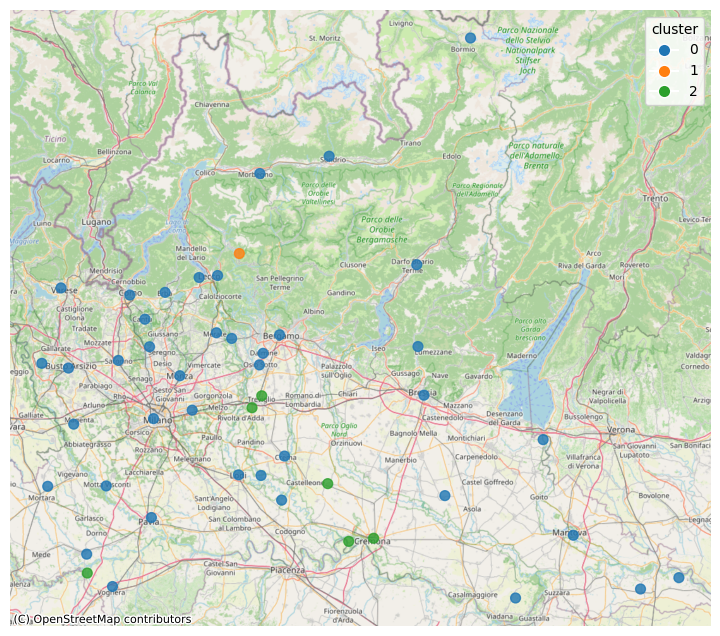

In [26]:
SQL_MUNI_LOC = """
SELECT m.municipality_id, l.latitude, l.longitude
FROM pap.municipality_dt m
JOIN pap.location_dt l ON l.location_id = m.location_id
"""
with engine.connect() as con:
    muni_geo = pd.read_sql(text(SQL_MUNI_LOC), con)

plot_df = muni_geo.merge(df_pivot, on="municipality_id")

gdf = gpd.GeoDataFrame(
    plot_df,
    geometry=gpd.points_from_xy(plot_df["longitude"], plot_df["latitude"]),
    crs="EPSG:4326"
).to_crs(3857)

from matplotlib.colors import ListedColormap, BoundaryNorm

n_clusters = df_pivot['cluster'].nunique()
cmap_discrete = ListedColormap([cluster_color_map[c] for c in range(n_clusters)])
bounds = np.arange(-0.5, n_clusters, 1)
norm = BoundaryNorm(bounds, cmap_discrete.N)

fig, ax = plt.subplots(figsize=(10, 8))
gdf.plot(column='cluster', ax=ax, cmap=cmap_discrete, norm=norm,
         legend=False, markersize=50, alpha=0.8)
ctx.add_basemap(ax, source=ctx.providers.OpenStreetMap.Mapnik)
ax.set_axis_off()

handles = [Line2D([0], [0], marker='o', color='w', markerfacecolor=cluster_color_map[c],
                  markersize=9, label=str(c)) for c in range(n_clusters)]
ax.legend(handles=handles, title='cluster', loc='best', framealpha=0.85)

plt.savefig(os.path.join(IMGS_DIR, 'cluster_geo_map.png'), dpi=150, bbox_inches='tight')
plt.show()


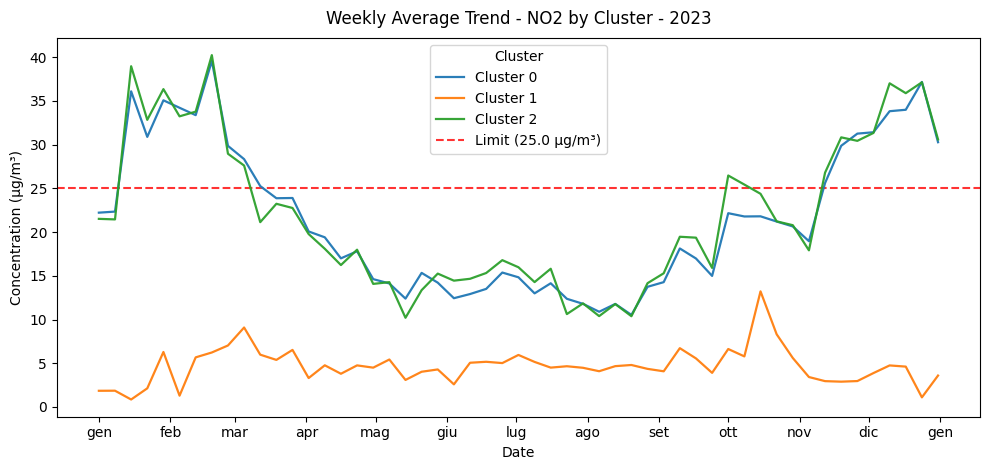

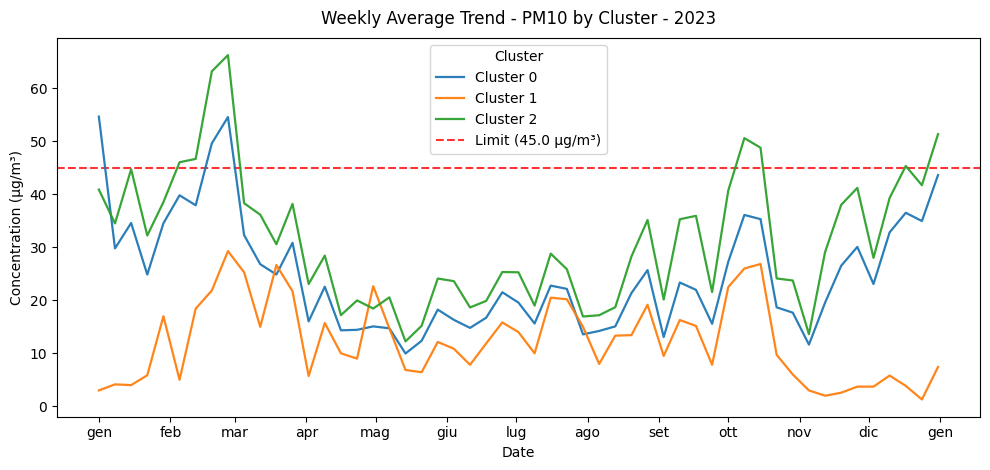

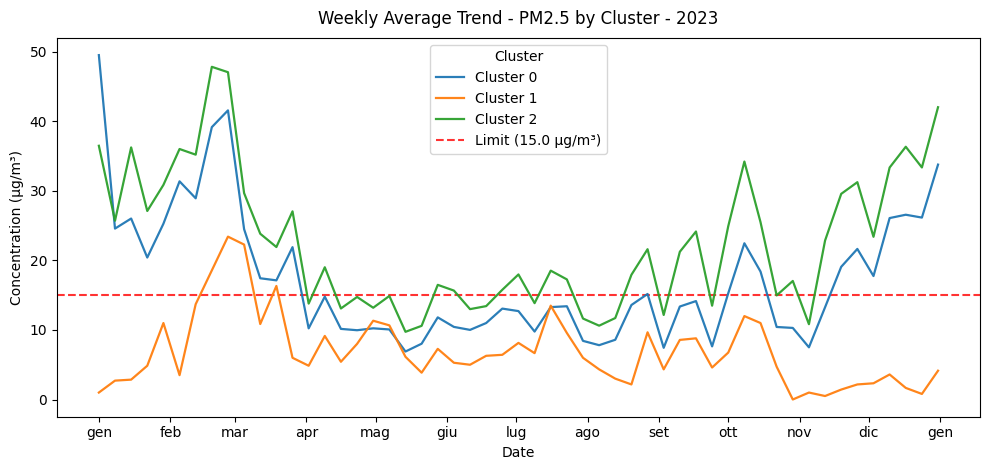

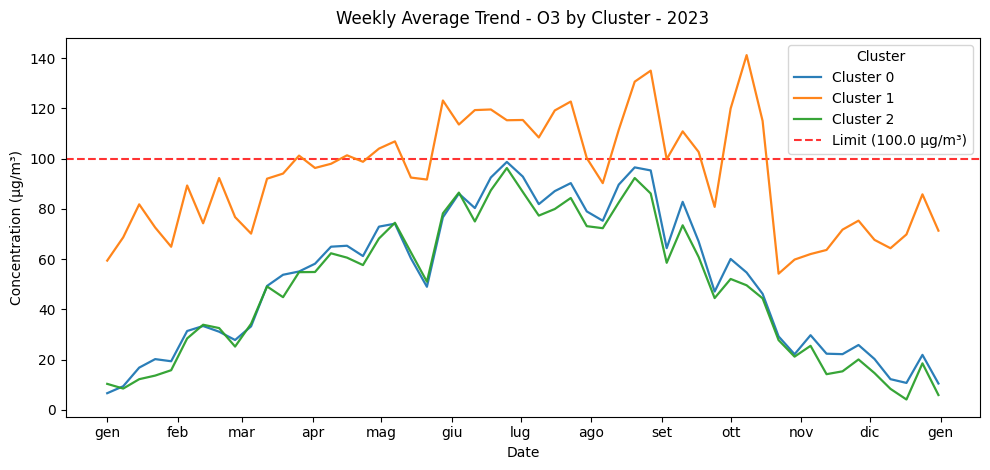

In [27]:
clusters_map = df_pivot[["municipality_id", "cluster"]].drop_duplicates()

SQL_DAILY = """
SELECT
  d.date AS date,
  s.name AS pollutant,
  m.urbanization,
  m.municipality_id,
  AVG(sf.mean_value) AS value
FROM pap.sample_ft sf
JOIN pap.sensor_dt s ON s.sensor_id = sf.sensor_id
JOIN pap.station_dt st ON st.station_id = s.station_id
JOIN pap.municipality_dt m ON m.municipality_id = st.municipality_id
JOIN pap.date_dt d ON d.date_id = sf.date_id
WHERE d.year = 2023
  AND s.name = ANY(:target_pollutants)
GROUP BY d.date, s.name, m.urbanization, m.municipality_id
"""

with engine.connect() as con:
    daily_raw = pd.read_sql(
        text(SQL_DAILY), con,
        params={"target_pollutants": TARGET_POLLUTANTS}
    )

daily_raw["date"] = pd.to_datetime(daily_raw["date"], errors="coerce")

daily_cluster = (
    daily_raw.merge(clusters_map, on="municipality_id", how="inner")
             .groupby(["date", "pollutant", "cluster"], as_index=False)
             .agg(avg_value=("value", "mean"))
)

all_clusters = sorted(clusters_map["cluster"].unique())
for pol in TARGET_POLLUTANTS:
    sub = daily_cluster[daily_cluster["pollutant"] == pol].copy()
    pivot = (
      sub.pivot(index="date", columns="cluster", values="avg_value")
         .sort_index()
         .resample('W').mean()
    )

    pivot = pivot.reindex(columns=all_clusters)
    short = POLLUTANT_SHORT.get(pol, pol)

    fig, ax = plt.subplots(figsize=(10, 4.8))
    for c in all_clusters:
        if c in pivot.columns:
            ax.plot(pivot.index, pivot[c], linewidth=1.6, alpha=0.95,
                    color=cluster_color_map[c], label=f'Cluster {c}', zorder=2)

    if pol in LIMITS:
      limit_value, unit = LIMITS[pol]
      ax.axhline(limit_value, color="red", linestyle="dashed", linewidth=1.5, alpha=0.8, label=f"Limit ({limit_value} {unit})", zorder=0)

    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b"))

    ax.set_title(f"Weekly Average Trend - {short} by Cluster - 2023", pad=10)
    ax.set_xlabel("Date")
    ax.set_ylabel(f"Concentration (µg/m³)")
    ax.grid(False)
    ax.legend(title="Cluster")

    plt.tight_layout()
    fig.savefig(os.path.join(IMGS_DIR, f'cluster_trend_{POLLUTANT_CODE[pol]}.png'), dpi=150, bbox_inches='tight')
    plt.show()


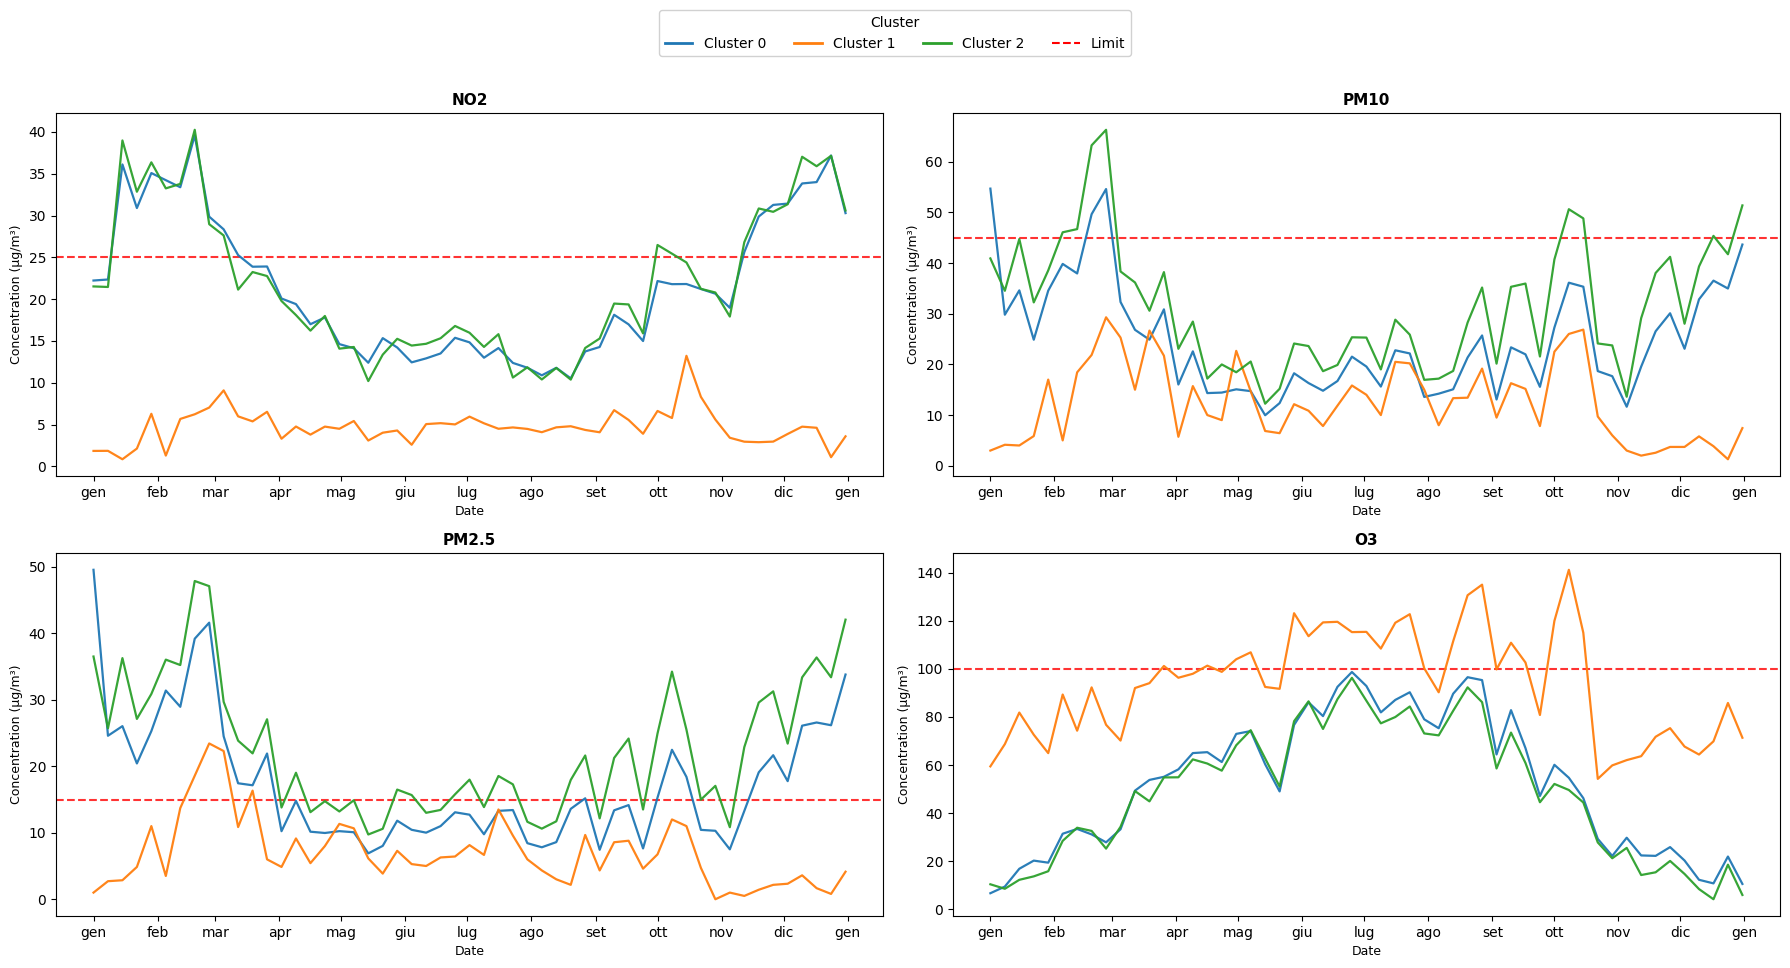

In [28]:
n_polls = len(TARGET_POLLUTANTS)
n_cols  = 2
n_rows  = (n_polls + 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 10), sharey=False)
axes = axes.flatten()

for ax_idx, pol in enumerate(TARGET_POLLUTANTS):
    ax    = axes[ax_idx]
    short = POLLUTANT_SHORT.get(pol, pol)

    sub   = daily_cluster[daily_cluster["pollutant"] == pol].copy()
    pivot = (
        sub.pivot(index="date", columns="cluster", values="avg_value")
           .sort_index()
           .resample('W').mean()
    )
    pivot = pivot.reindex(columns=all_clusters)

    for c in all_clusters:
        if c in pivot.columns:
            ax.plot(pivot.index, pivot[c], linewidth=1.6, alpha=0.95,
                    color=cluster_color_map[c], label=f'Cluster {c}', zorder=2)

    if pol in LIMITS:
        limit_value, unit = LIMITS[pol]
        ax.axhline(limit_value, color="red", linestyle="dashed", linewidth=1.5,
                   alpha=0.8, label=f"Limit ({limit_value} {unit})", zorder=0)

    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b"))
    ax.set_title(f'{short}', fontsize=11, fontweight='bold')
    ax.set_xlabel("Date", fontsize=9)
    ax.set_ylabel("Concentration (µg/m³)", fontsize=9)
    ax.grid(False)

for j in range(n_polls, len(axes)):
    axes[j].set_visible(False)

cluster_handles = [
    Line2D([0], [0], color=cluster_color_map[c], linewidth=2, label=f'Cluster {c}')
    for c in all_clusters
]
limit_handle = Line2D([0], [0], color='red', linewidth=1.5, linestyle='--', label='Limit')
fig.legend(handles=cluster_handles + [limit_handle],
           loc='upper center', ncol=len(all_clusters) + 1,
           fontsize=10, title='Cluster', title_fontsize=10,
           framealpha=0.9, bbox_to_anchor=(0.5, 0.97))
fig.suptitle("")
plt.tight_layout(rect=[0, 0, 1, 0.91])
fig.savefig(os.path.join(IMGS_DIR, 'cluster_trend_combined.png'), dpi=150, bbox_inches='tight')
plt.show()


In [29]:

limits = {POLLUTANT_CODE[k]: v[0] for k, v in LIMITS.items()}

cluster_pollution = df_pivot.groupby('cluster')[cluster_cols].mean()
cluster_normalized = cluster_pollution.copy()
for col in cluster_cols:
    cluster_normalized[col] = cluster_pollution[col] / limits[col]

cluster_normalized['pollution_index'] = cluster_normalized[cluster_cols].mean(axis=1)
cluster_ranking = cluster_normalized['pollution_index'].sort_values(ascending=False)

print("Cluster Pollution Index")
display(cluster_ranking.round(3))
cluster_ranking.round(3).to_frame('pollution_index').to_csv(os.path.join(TABS_DIR, 'cluster_pollution_index.csv'))


Cluster Pollution Index


cluster
2    0.887
0    0.779
1    0.471
Name: pollution_index, dtype: float64

In [30]:

sql_urb_dist = """
SELECT
    m.urbanization,
    COUNT(DISTINCT m.municipality_id) AS n_municipalities
FROM pap.municipality_dt m
JOIN pap.station_dt st ON st.municipality_id = m.municipality_id
JOIN pap.sensor_dt se ON se.station_id = st.station_id
WHERE se.name = ANY(:target_pollutants)
  AND m.urbanization IS NOT NULL
GROUP BY m.urbanization
ORDER BY n_municipalities DESC;
"""

with engine.connect() as con:
    df_urb_dist = pd.read_sql(text(sql_urb_dist), con, params={"target_pollutants": TARGET_POLLUTANTS})

df_urb_dist['urb_short'] = df_urb_dist['urbanization'].map(lambda x: URBAN_SHORT.get(x, x))
df_urb_dist['urb_short'] = pd.Categorical(df_urb_dist['urb_short'], categories=URBAN_ORDER, ordered=True)
df_urb_dist = df_urb_dist.sort_values('urb_short').reset_index(drop=True)

total_muni = df_urb_dist['n_municipalities'].sum()
df_urb_dist['percentage'] = (df_urb_dist['n_municipalities'] / total_muni * 100).round(1)

display(df_urb_dist[['urb_short', 'n_municipalities', 'percentage']].rename(columns={
    'urb_short': 'Urbanization', 'n_municipalities': 'Municipalities', 'percentage': '%'
}))

,Urbanization,Municipalities,%
0,Dense,30,23.1
1,Intermediate,74,56.9
2,Rural,26,20.0
